In [424]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [425]:
cisne_branco = cv.imread("veleiro.jpg")
cisne_branco_norm = cisne_branco / 255 

In [426]:
pc = cv.imread("PoucoContraste.png")
pc = pc/255

# 1. Alterando Brilho e Contraste

In [427]:
def brigthness_contrast_modifier(img, alpha: float, beta: float = None):
    
    if -1<= alpha <= 1:
        imagem = img + alpha
        
    if beta:
        if 0 <= beta <= 1:
            if len(imagem.shape) > 2:
                for i in range(imagem.shape[2]):
                    chanel = imagem[:, :, i]
                    chanel = beta * (chanel - np.mean(chanel)) + np.mean(chanel)
                    imagem[:, :,i] =  chanel
            else:
                imagem = beta * (imagem - np.mean(imagem)) + np.mean(imagem)
    
    imagem = np.clip(imagem, 0, 1)
    return imagem

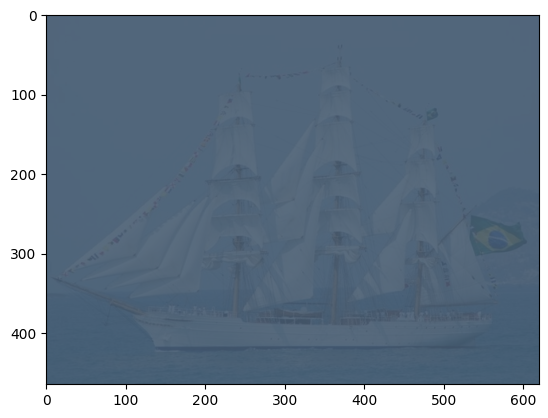

In [428]:
im = brigthness_contrast_modifier(cisne_branco_norm[:, :, ::-1], -0.3, 0.1)
plt.imshow(im)

# 2. Histograma

In [429]:
cb_luminancia_alt = brigthness_contrast_modifier(cisne_branco_norm, 0.2)
cb_contraste_alt = brigthness_contrast_modifier(cisne_branco_norm, 0, 0.4)

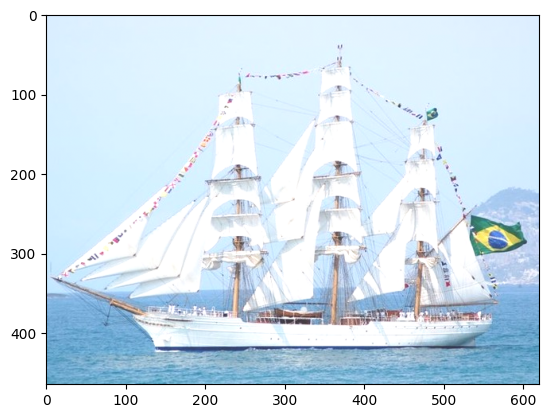

In [430]:
plt.imshow(cb_luminancia_alt[: ,:, ::-1])

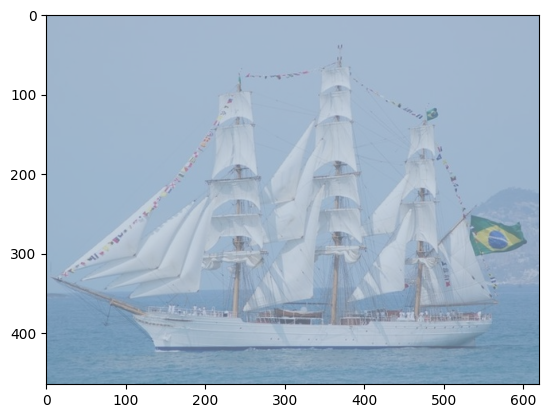

In [431]:
plt.imshow(cb_contraste_alt[: ,:, ::-1])

0
1
2
0
1
2
0
1
2


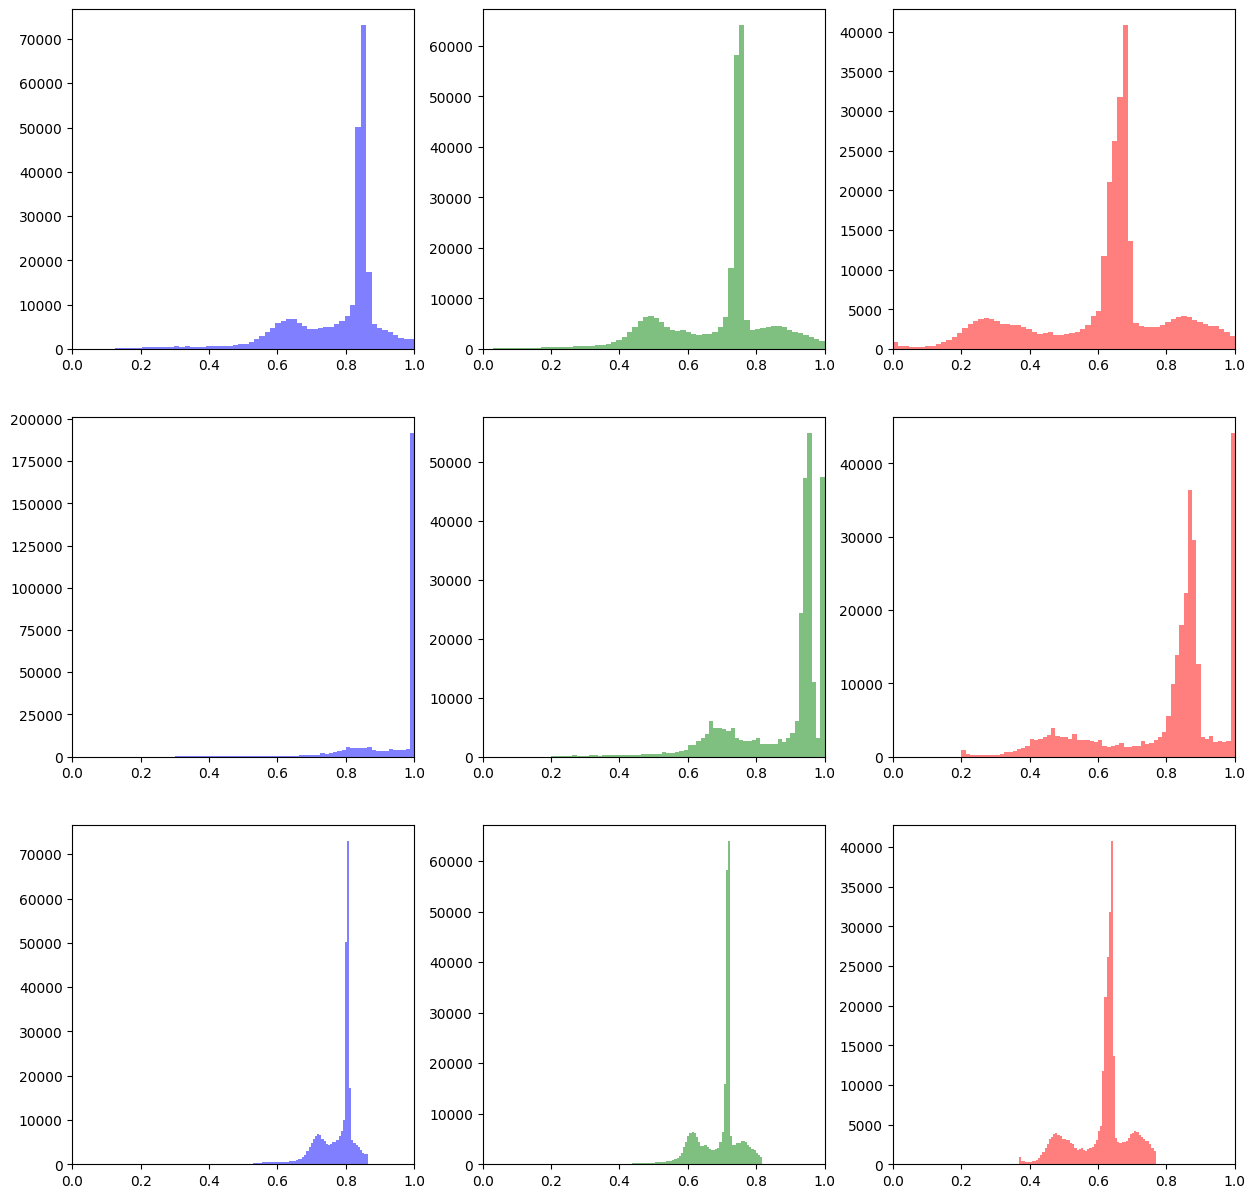

In [432]:
fig, ax = plt.subplots(3, 3, figsize = (15, 15))

b, g, r = cv.split(cisne_branco_norm)
b1, g1, r1 = cv.split(cb_luminancia_alt)
b2, g2, r2 = cv.split(cb_contraste_alt)

chanels = [(b, g, r), (b1, g1, r1), (b2, g2, r2)]


for i in range(len(chanels)):
    for j in range(len(chanels[i])):
        if j == 0:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "blue", alpha=0.5)
        elif j == 1:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "green", alpha=0.5)
        elif j == 2:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "red", alpha=0.5)
        ax[i,j].set_xlim(0,1)
        print(j)
    

In [433]:
pc_luminancia_alt = brigthness_contrast_modifier(pc, 0.2)
pc_contraste_alt = brigthness_contrast_modifier(pc, 0, 0.4)

0
1
2
0
1
2
0
1
2


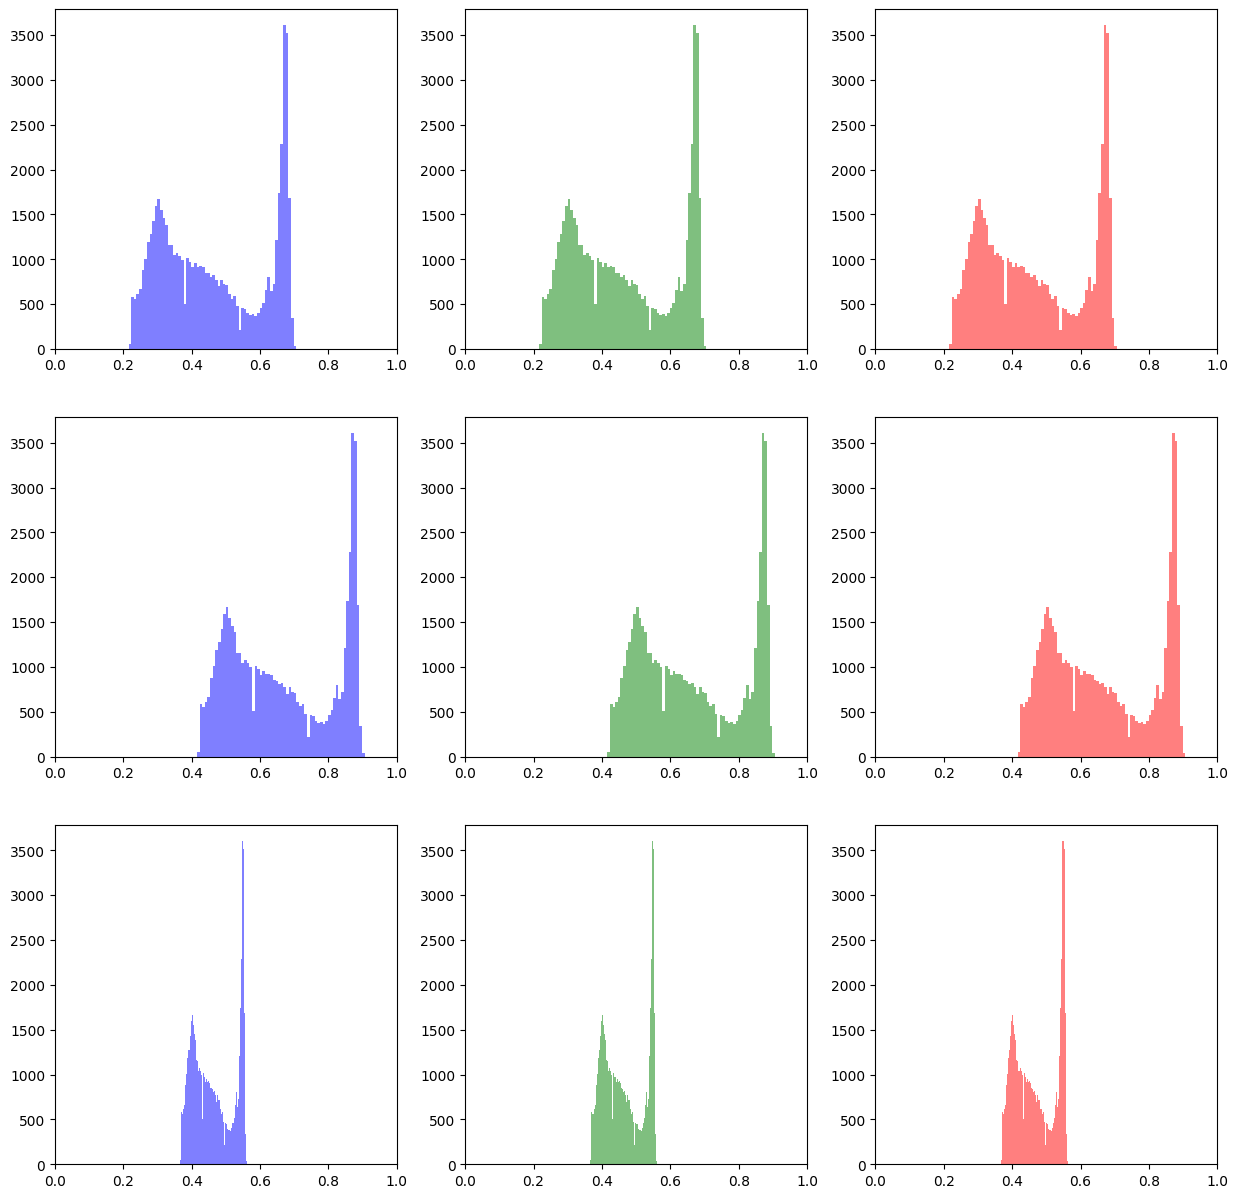

In [434]:
fig, ax = plt.subplots(3, 3, figsize = (15, 15))

b, g, r = cv.split(pc)
b1, g1, r1 = cv.split(pc_luminancia_alt)
b2, g2, r2 = cv.split(pc_contraste_alt)

chanels = [(b, g, r), (b1, g1, r1), (b2, g2, r2)]


for i in range(len(chanels)):
    for j in range(len(chanels[i])):
        if j == 0:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "blue", alpha=0.5)
        elif j == 1:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "green", alpha=0.5)
        elif j == 2:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "red", alpha=0.5)
        ax[i,j].set_xlim(0,1)
        print(j)

In [435]:
cv_cb_luminancia_alt = cv.convertScaleAbs(cisne_branco, alpha= 1.2, beta= 0)
cv_cb_contraste_alt = cv.convertScaleAbs(cisne_branco, alpha= 1, beta= 100)

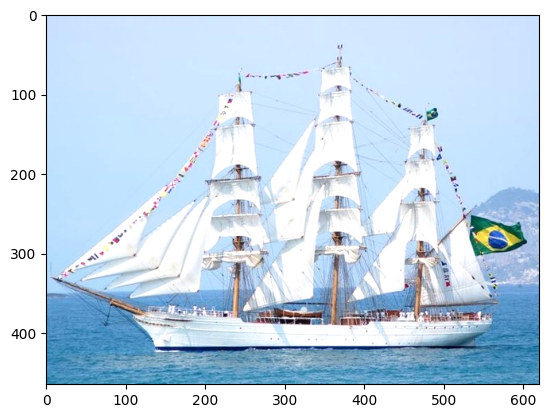

In [436]:
plt.imshow(cv_cb_luminancia_alt[: ,:, ::-1])

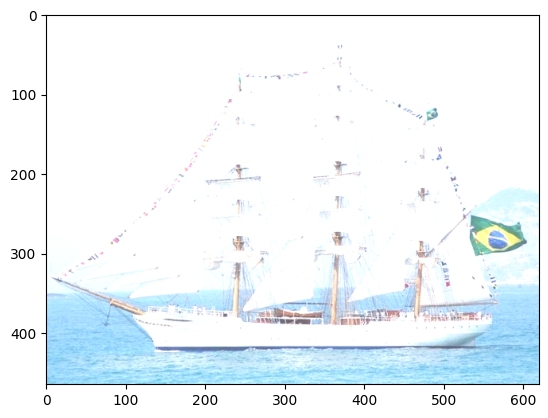

In [437]:
plt.imshow(cv_cb_contraste_alt[: ,:, ::-1])

0
1
2
0
1
2
0
1
2


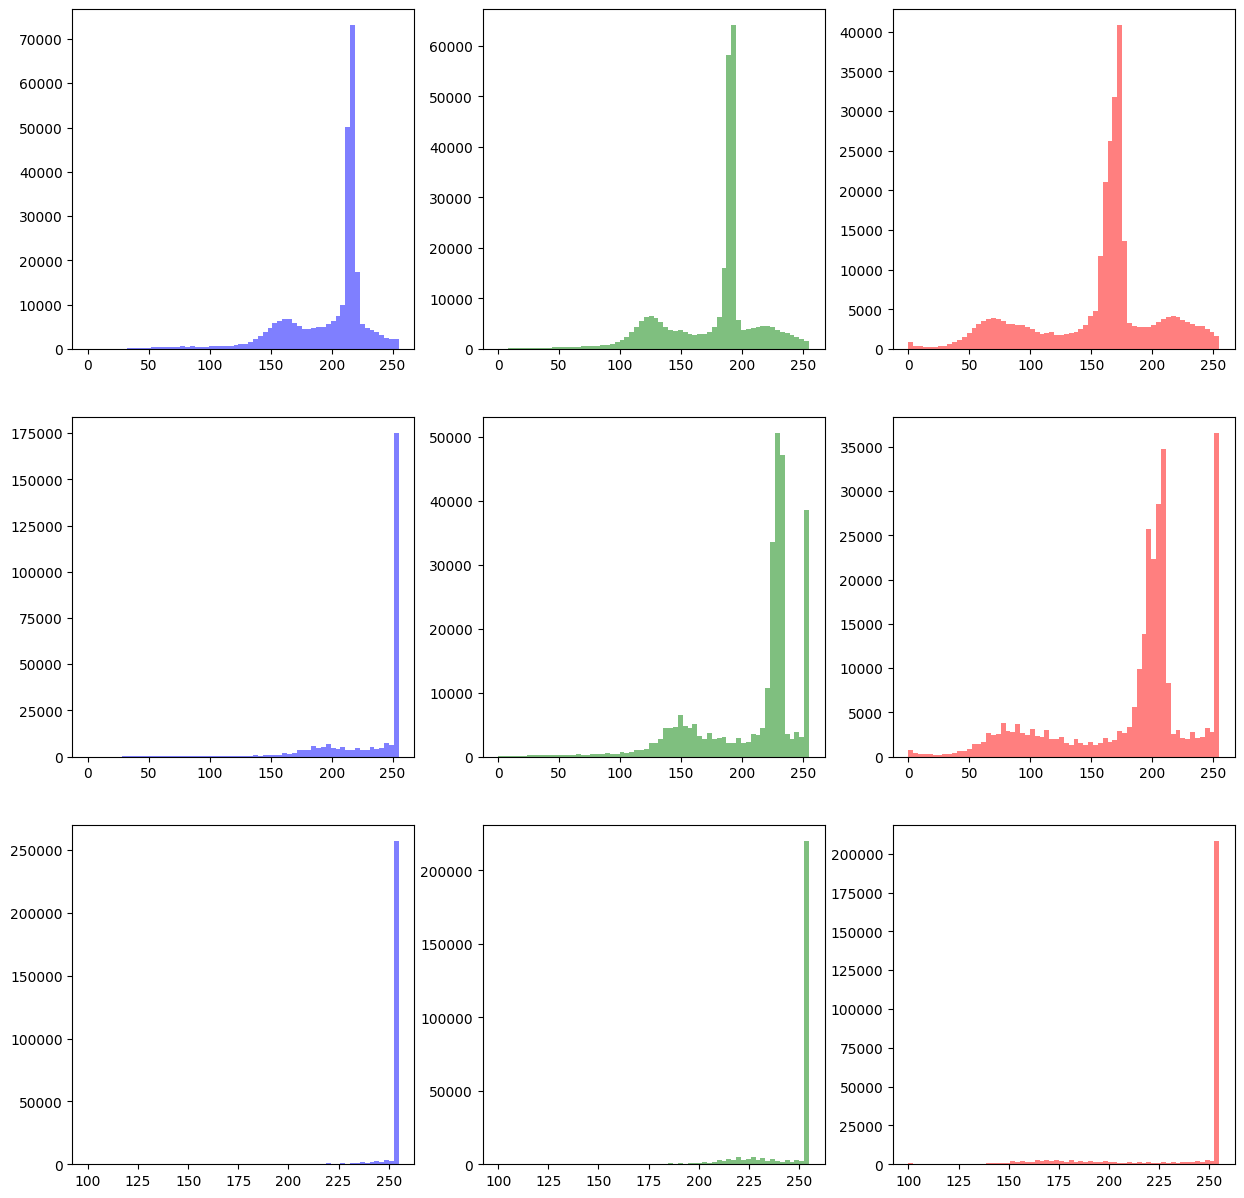

In [438]:
fig, ax = plt.subplots(3, 3, figsize = (15, 15))

b, g, r = cv.split(cisne_branco)
b1, g1, r1 = cv.split(cv_cb_luminancia_alt)
b2, g2, r2 = cv.split(cv_cb_contraste_alt)

chanels = [(b, g, r), (b1, g1, r1), (b2, g2, r2)]


for i in range(len(chanels)):
    for j in range(len(chanels[i])):
        if j == 0:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "blue", alpha=0.5)
        elif j == 1:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "green", alpha=0.5)
        elif j == 2:
            ax[i,j].hist(chanels[i][j].flatten(), bins= 64, color= "red", alpha=0.5)
        print(j)